# Tutorial 2-2: Play with Gradient Descent in Python


In [5]:
import numpy as np
import matplotlib.pyplot as plt

# Make numerical output concise and the random initialization reproducible.
np.set_printoptions(precision=6, suppress=True)
np.random.seed(42)

## 1.1 Basic implementation

- Objective function: $f(x)=x^2$
- Gradient: $\nabla f(x)=2x$
- Convergence criterion: $|f(x^*)-f(x)|\leq 0.01$
- Learning rate: $\alpha=0.4$

Because the minimum is $f(x^*)=0$, the stopping condition becomes $|f(x)|\leq 0.01$.

In [6]:
f = lambda x: x**2       # Objective function
df = lambda x: 2 * x     # Gradient

epsilon = 0.01           # Convergence threshold
alpha = 0.4              # Learning rate

# Initialization
x = 10.0
print("Initialize: x =", x)
print()

# Start gradient descent
iters = 0
while round(abs(f(x)), 10) > epsilon:
    x = round(x - alpha * df(x), 10)
    iters += 1
    print(f"==> Iter {iters}, x={x}, f(x)={round(f(x), 10)}")

print("------------- The model is converged -------------")
print("\nOptimal solution =", x)
print("Minimum f(x) = x^2 =", f(x))

Initialize: x = 10.0

==> Iter 1, x=2.0, f(x)=4.0
==> Iter 2, x=0.4, f(x)=0.16
==> Iter 3, x=0.08, f(x)=0.0064
------------- The model is converged -------------

Optimal solution = 0.08
Minimum f(x) = x^2 = 0.0064


### What happened?

The update rule is

$$
x_{k+1}=x_k-\alpha\nabla f(x_k)
=x_k-0.4(2x_k)=0.2x_k.
$$

Thus, each update reduces $x$ to 20% of its previous value. Starting from $x_0=10$, the sequence is $10\rightarrow2\rightarrow0.4\rightarrow0.08$.


## 1.2 Encapsulation of gradient descent

We now package the algorithm as a reusable function. The objective function, gradient, learning rate, convergence rule, initial value, and iteration limit are all passed as arguments.

In [7]:
def grad_descent(obj_fn, grad_fn, alpha, is_converge, init_x, max_iters=100):
    """Minimize obj_fn using gradient descent."""
    x = np.array(init_x, dtype=float)
    x_last = np.full_like(x, np.inf, dtype=float)

    iters = 0
    while not is_converge(obj_fn(x_last), obj_fn(x)):
        x_last = x.copy()
        x = x - alpha * grad_fn(x)
        iters += 1

        print("x: ",x)
        if iters >= max_iters:
            print(f"Not converged in {iters} steps")
            return x

    print(f"Converged in {iters} steps")
    print("Optimal solution =", x)
    print("Minimum objective value =", obj_fn(x))
    return x

In [8]:
f = lambda x: x**2
df = lambda x: 2 * x

epsilon = 0.01
alpha = 0.4
x0 = 10.0

converge_criterion = lambda last, curr: abs(curr) <= epsilon
x_optim = grad_descent(f, df, alpha, converge_criterion, x0)

x:  2.0
x:  0.3999999999999999
x:  0.07999999999999996
Converged in 3 steps
Optimal solution = 0.07999999999999996
Minimum objective value = 0.006399999999999993


## 1.3 Verify the non-convergent example

Keep the same problem but set the learning rate to $\alpha=1$.

The update becomes

$$
x_{k+1}=x_k-1(2x_k)=-x_k.
$$

Therefore, the sequence alternates between $10$ and $-10$ and never approaches zero.

In [9]:
alpha = 1.0
x0 = 10.0

x_not_converged = grad_descent(
    f,
    df,
    alpha,
    converge_criterion,
    x0,
    max_iters=100,
)

print("Final x returned after reaching max_iters =", x_not_converged)
print("Final f(x) =", f(x_not_converged))

x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
x:  -10.0
x:  10.0
Not converged in 100 steps
Final x returned after 

## 1.4 Gradient descent for logistic regression

We next apply the same optimization idea to binary classification.

### 1.4.1 Data generation

The dataset contains six samples, two features $(x_1,x_2)$, and binary labels $y\in\{0,1\}$.

In [83]:
# Feature 1
raw_x1 = [0.959, 0.750, 0.395, 0.823, 0.761, 0.844]

# Feature 2
raw_x2 = [0.382, 0.306, 0.760, 0.764, 0.874, 0.435]

# Observed labels
raw_labels = [0, 0, 1, 1, 1, 0]

data_X = np.stack([raw_x1, raw_x2], axis=1)
print("data_X:\n", data_X)

gt_Y = np.array(raw_labels, dtype=np.float32)[:, np.newaxis]
print("\ngt_Y:\n", gt_Y)

data_X:
 [[0.959 0.382]
 [0.75  0.306]
 [0.395 0.76 ]
 [0.823 0.764]
 [0.761 0.874]
 [0.844 0.435]]

gt_Y:
 [[0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]]


### 1.4.2 Data visualization

The two classes are plotted with different colors. Each point is also annotated with its ground-truth label.

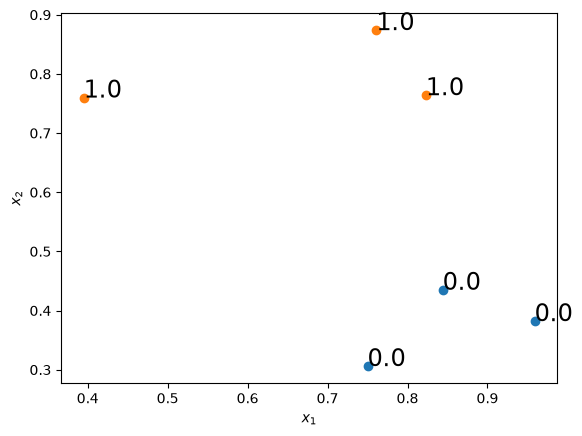

In [84]:
# Plot data points with label = 0
neg_labels_idx = gt_Y[:,0] == 0
plt.scatter(data_X[neg_labels_idx, 0], data_X[neg_labels_idx, 1])
# Plot data points with label = 1
pos_labels_idx = gt_Y[:,0] == 1
plt.scatter(data_X[pos_labels_idx, 0], data_X[pos_labels_idx, 1])
# Annotate each point with its ground truth label
for i, txt in enumerate(gt_Y[:, 0]):
    plt.annotate(txt, data_X[i,0:2], fontsize=17)
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

### 1.4.3 Logistic regression

For a feature vector $\mathbf{x}$ and parameter vector $\boldsymbol{\theta}$, the model predicts

$$
P(y=1\mid\mathbf{x})=\sigma(\mathbf{x}^{\mathsf T}\boldsymbol{\theta}),
\qquad
\sigma(z)=\frac{1}{1+e^{-z}}.
$$

The parameters are learned by minimizing the binary cross-entropy loss.

In [73]:
# Sigmoid function
sigmoid = lambda z: 1.0 / (1 + np.exp(-z))

# Probability P(Y=1|X), parameterized by Theta
P = lambda X, Theta: np.clip(sigmoid(X @ Theta), 1e-3, 1 - 1e-3)

# Cross-entropy loss
def ce_loss(X, Theta, Y_true):
    return np.sum(-Y_true * np.log(P(X, Theta)) - (1.0 - Y_true) * np.log(1 - P(X, Theta)))

def d_ce_loss(X, Theta, Y_true):
    return X.T @ (P(X, Theta) - Y_true)

# d_ce_loss = lambda X, Theta, Y_true: np.sum((P(X, Theta) - Y_true) * X, axis=0,
# keepdims=True).T # Output: column vector

# Probability to category
def prob2category(prob_ls, threshold = 0.5):
    prob_ls = prob_ls.copy()
    prob_ls[prob_ls >= 0.5] = 1
    prob_ls[prob_ls < 0.5] = 0
    return prob_ls

# grad_descent
def grad_descent(obj_fn, grad_fn, alpha, is_converge, init_x, max_iters = 100):
    # initialize x and x_lst
    x = init_x
    x_last = np.inf * np.ones_like(init_x)
    # Start gradient descent
    iters = 0
    while not is_converge(obj_fn(x_last), obj_fn(x)):
        x_last = x
        x = x - alpha * grad_fn(x)
        iters += 1
        if iters >= max_iters:
            print('Not converged in %s steps' % iters)
            return x
    print('Converged in %s steps' % iters)
    # Return optimal solution
    return x

In [76]:
def logistic_regress(X, Y, learning_rate = 0.01):
    # Note that Theta should be in 2-dimensional real space
    Theta_0 = np.random.randn(X.shape[1], 1)
    converge_criterion3 = lambda last, curr: abs(last - curr) < 1e-4
    obj_f = lambda Theta: ce_loss(X, Theta, Y)
    d_obj_f = lambda Theta: d_ce_loss(X, Theta, Y)
    # Use gradient descent to find the best model
    Theta_optim = grad_descent(obj_f, d_obj_f, learning_rate, converge_criterion3,
                               Theta_0, max_iters=10000)
    return Theta_optim


Theta_optim_1 = logistic_regress(data_X, gt_Y)
print("Theta_optim_1", Theta_optim_1)

prob_ls = P(data_X, Theta_optim_1)
pred_Y = prob2category(prob_ls)
print("pred_Y", pred_Y)

Converged in 4867 steps
Theta_optim_1 [[-6.637329]
 [ 9.064343]]
pred_Y [[0.]
 [0.]
 [1.]
 [1.]
 [1.]
 [0.]]


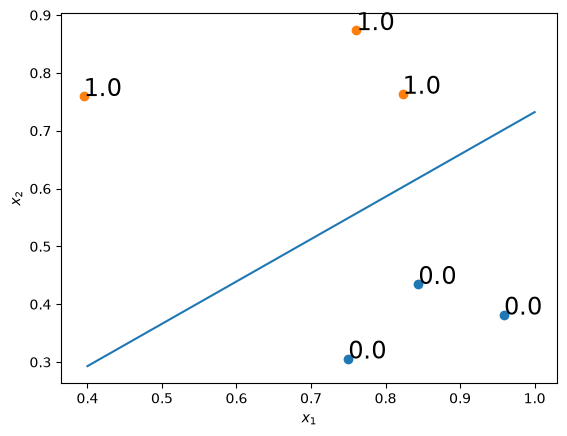

In [77]:
# Plot data points with label = 0
neg_labels_idx = pred_Y[:,0] == 0
plt.scatter(data_X[neg_labels_idx, 0], data_X[neg_labels_idx, 1])

# Plot data points with label = 1
pos_labels_idx = pred_Y[:,0] == 1
plt.scatter(data_X[pos_labels_idx, 0], data_X[pos_labels_idx, 1])

# Annotate each point with its ground truth label
for i, txt in enumerate(gt_Y[:, 0]):
    plt.annotate(txt, data_X[i,0:2], fontsize=17)
    
# Draw decision boundary
range_x1 = np.linspace(0.4, 1, 100)
lin_eq = lambda x1: -Theta_optim_1[0] * x1 / Theta_optim_1[1]
plt.plot(range_x1, lin_eq(range_x1))
plt.xlabel('$x_1$')
plt.ylabel('$x_2$')
plt.show()

## Summary

- Gradient descent repeatedly moves parameters in the direction opposite to the gradient.
- The learning rate controls the update size and can determine whether optimization converges.
- The same reusable optimizer can minimize a scalar function or train a multi-parameter classifier.
- Logistic regression converts a linear score into a probability and learns its parameters by minimizing cross-entropy.